## Regional SAT anomalies calculation then calculate the trend

In [1]:
# In[1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
# %%
# define function
import src.SAT_function_Obs_Fingerprint as data_process
import src.Data_Preprocess as preprocess

In [2]:
# import src.slurm_cluster as scluster
# client, scluster = scluster.init_dask_slurm_cluster(scale=2,cores=10, memory="200GB")

In [3]:
# load data
MODELS = ['CESM2', 'CanESM5', 'ACCESS', 'EC_Earth3', 'IPSL_CM6A', 'MIROC6', 'MPI_ESM']
model = MODELS[0]
dir_in = f'/work/mh0033/m301036/OBS_LPS_revision/docs/data/FIG3/{model}/SMILE_forced/'
forced_Trend = xr.open_dataset(dir_in + f'{model}_ENSmean_forced_MK_trend_1950-2022_sliding.nc')

In [4]:
forced_Trend

<xarray.Dataset>
Dimensions:  (lon: 180, lat: 90, period: 64)
Coordinates:
  * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
  * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
  * period   (period) object '1950-2022' '1951-2022' ... '2012-2022' '2013-2022'
Data variables:
    trend    (period, lat, lon) float64 ...
    p_value  (period, lat, lon) float64 ...

### Calculate the trend end year fix to 2022, start with 73 year length and decrease length of trend every one year, the minimum trend length is 10yr 

In [5]:
temp_data = forced_Trend.trend

In [6]:
#Perfrom land sea mask
land_sea_mask=xr.open_dataset('/work/mh0033/m301036/Data_storage/CMIP6-MPI-ESM-LR/GR15_lsm_regrid.nc')
# land_sea_mask.coords
land_sea_mask

# mask the land area trend data
mask_data = land_sea_mask['var1']
mask_data

<xarray.DataArray 'var1' (time: 1, lat: 90, lon: 180)>
[16200 values with dtype=float32]
Coordinates:
  * time     (time) float64 201.0
  * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
  * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
Attributes:
    code:     1

In [7]:
# Apply the land-sea mask to the trend data, mask the land area trend
temp_data_masked = temp_data.where(mask_data[0,:,:]==0, drop = False)

In [8]:
temp_data

<xarray.DataArray 'trend' (period: 64, lat: 90, lon: 180)>
[1036800 values with dtype=float64]
Coordinates:
  * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
  * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
  * period   (period) object '1950-2022' '1951-2022' ... '2012-2022' '2013-2022'

In [9]:
# flip the longitude to -180 to 180
temp_data_adj = preprocess.convert_longitude(temp_data)

In [10]:
temp_data_masked_adj = preprocess.convert_longitude(temp_data_masked)

In [11]:
temp_data_adj

<xarray.DataArray 'trend' (period: 64, lat: 90, lon: 180)>
[1036800 values with dtype=float64]
Coordinates:
  * lon      (lon) float64 -180.0 -178.0 -176.0 -174.0 ... 174.0 176.0 178.0
  * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
  * period   (period) object '1950-2022' '1951-2022' ... '2012-2022' '2013-2022'

In [12]:
type(temp_data_adj)

xarray.core.dataarray.DataArray

### Regional anomalies calculation

In [13]:
def plot_trend(temp_data, lats, lons, levels=None, extend=None, cmap=None, 
                                 title="", ax=None, show_xticks=False, show_yticks=False):
    """
    Plot the trend spatial pattern using Robinson projection with significance overlaid.

    Parameters:
    - temp_data: 2D numpy array with the trend values.
    - lats, lons: 1D arrays of latitudes and longitudes.
    - p_values: 2D array with p-values for each grid point.
    - GMST_p_values: 2D array with GMST p-values for each grid point.
    - title: Title for the plot.
    - ax: Existing axis to plot on. If None, a new axis will be created.
    - show_xticks, show_yticks: Boolean flags to show x and y axis ticks.
    
    Returns:
    - contour_obj: The contour object from the plot.
    """
    # Plotting
    contour_obj = ax.contourf(lons, lats, temp_data, levels=levels, extend=extend, cmap=cmap, transform=ccrs.PlateCarree())

    ax.coastlines(resolution='110m')
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False,
                      color='gray', alpha=0.35, linestyle='--')

    # Disable labels on the top and right of the plot
    gl.top_labels = False
    gl.right_labels = False

    # Enable labels on the bottom and left of the plot
    gl.bottom_labels = show_xticks
    gl.left_labels = show_yticks
    gl.xformatter = cticker.LongitudeFormatter()
    gl.yformatter = cticker.LatitudeFormatter()
    gl.xlabel_style = {'size': 16}
    gl.ylabel_style = {'size': 16}
    
    if show_xticks:
        gl.bottom_labels = True
    if show_yticks:
        gl.left_labels = True
    
    # ax.set_title(title, loc='center', fontsize=18, pad=5.0)

    return contour_obj
# %%
plt.rcParams['figure.figsize'] = (8, 10)
plt.rcParams['font.size'] = 16
# plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['ytick.direction'] = 'out'
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['ytick.major.right'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.pad_inches'] = 0.1
plt.rcParams['savefig.transparent'] = True

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as mticker
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
import matplotlib as mpl
import seaborn as sns
from matplotlib.colors import ListedColormap
from matplotlib.colors import BoundaryNorm, ListedColormap
import cartopy.util as cutil
import seaborn as sns
import matplotlib.colors as mcolors
import palettable

In [14]:
levels = np.arange(-3.5, 4.0, 0.25)

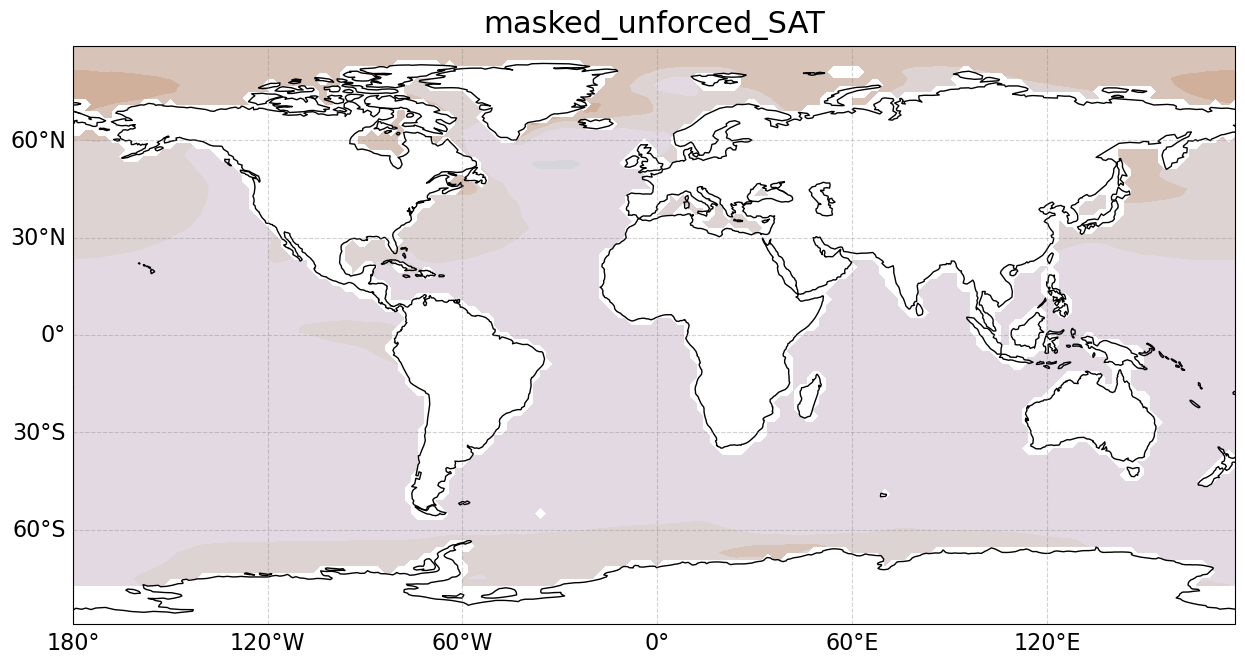

In [15]:
# Plot the North Atlantic region's temperature anomalies map
region_sel = temp_data_masked_adj.sel(period='1979-2022')
region_sel

fig = plt.figure(figsize=(15, 10))
gs = gridspec.GridSpec(1, 1, figure=fig, hspace=0.01, wspace=0.01)

ax = fig.add_subplot(gs[0,0], projection=ccrs.PlateCarree(central_longitude=0))
# ax.set_global()
# pvalue_annual_da_with_cyclic, _ = cutil.add_cyclic_point(pvalue_annual_da['40yr'], coord=lon)
contour_obj = plot_trend(region_sel, region_sel.lat, region_sel.lon, levels=levels,extend='both', cmap='twilight_shifted',
            title=" ", ax=ax, show_xticks=True, show_yticks=True)
ax.set_title('masked_unforced_SAT', fontsize=22, pad=10.0)

plt.show()

In [16]:
lat = temp_data_adj.lat
lon = temp_data_adj.lon

lat1 = 42
lat2 = 60
lon1 = -50
lon2 = -10

In [17]:
def calc_North_Atlantic_anomalies(data,mask_data):
    ds_WH = data.sel(lat=slice(42, 60), lon=slice(-50, -10))
    ds_WH_anomaly = data_process.calc_weighted_mean(ds_WH)
    ds_sel = mask_data.sel(lat=slice(0, 90), lon=slice(-180,180))
    ds_sel_anomaly = data_process.calc_weighted_mean(ds_sel)
    
    ds_anomalies = ds_WH_anomaly - ds_sel_anomaly
    return ds_anomalies

In [18]:
temp_data_adj_subpolar_gyre = calc_North_Atlantic_anomalies(temp_data_adj,temp_data_masked_adj)

In [19]:
temp_data_adj_subpolar_gyre

<xarray.DataArray 'trend' (period: 64)>
array([-0.04910667, -0.05004405, -0.0513902 , -0.05313296, -0.05448735,
       -0.05580178, -0.05747767, -0.05927886, -0.0607957 , -0.06250222,
       -0.06381413, -0.06489544, -0.06611353, -0.0674228 , -0.06960993,
       -0.07285648, -0.07728382, -0.0811214 , -0.0861723 , -0.09170918,
       -0.09662008, -0.10217598, -0.108168  , -0.11369226, -0.11969634,
       -0.12529936, -0.13067583, -0.13388777, -0.1405845 , -0.14559852,
       -0.15131398, -0.15889629, -0.16581863, -0.17576214, -0.18388719,
       -0.19098272, -0.19655039, -0.2018346 , -0.20893299, -0.22024872,
       -0.23037465, -0.24270481, -0.25447155, -0.25928354, -0.26422317,
       -0.26698937, -0.2696848 , -0.27368978, -0.28001532, -0.28574357,
       -0.28925589, -0.28904824, -0.2939328 , -0.2966054 , -0.30469637,
       -0.3085547 , -0.31745337, -0.3287879 , -0.33892446, -0.34900169,
       -0.3543636 , -0.34893997, -0.33009902, -0.30035068])
Coordinates:
  * period   (period) object '1950-2022' '1951-2022' ... '2012-2022' '2013-2022'
    time     float64 201.0

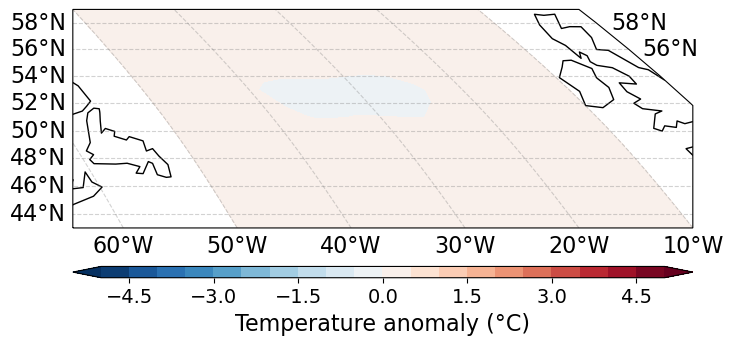

In [20]:
# da_plot_subpolar_gyre = temp_internal_da_subpolar_gyre.sel(year=2020)
da_plot = temp_data_adj.sel(period="1979-2022").sel(lat=slice(lat1, lat2), lon=slice(lon1, lon2))

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.Robinson(central_longitude=180)})

contour_obj =  plot_trend(da_plot, da_plot.lat, da_plot.lon, levels=np.arange(-5, 5.5, 0.5), extend='both', cmap='RdBu_r',
                                    title="subpolar_gyre region SAT anomaly 2020", ax=ax, show_xticks=True, show_yticks=True)

# colorbar
cbar = plt.colorbar(contour_obj, ax=ax, orientation='horizontal', pad=0.05, aspect=50)
cbar.set_label('Temperature anomaly (°C)')
cbar.ax.tick_params(labelsize=14)

plt.show()


In [21]:
temp_data_adj_subpolar_gyre

<xarray.DataArray 'trend' (period: 64)>
array([-0.04910667, -0.05004405, -0.0513902 , -0.05313296, -0.05448735,
       -0.05580178, -0.05747767, -0.05927886, -0.0607957 , -0.06250222,
       -0.06381413, -0.06489544, -0.06611353, -0.0674228 , -0.06960993,
       -0.07285648, -0.07728382, -0.0811214 , -0.0861723 , -0.09170918,
       -0.09662008, -0.10217598, -0.108168  , -0.11369226, -0.11969634,
       -0.12529936, -0.13067583, -0.13388777, -0.1405845 , -0.14559852,
       -0.15131398, -0.15889629, -0.16581863, -0.17576214, -0.18388719,
       -0.19098272, -0.19655039, -0.2018346 , -0.20893299, -0.22024872,
       -0.23037465, -0.24270481, -0.25447155, -0.25928354, -0.26422317,
       -0.26698937, -0.2696848 , -0.27368978, -0.28001532, -0.28574357,
       -0.28925589, -0.28904824, -0.2939328 , -0.2966054 , -0.30469637,
       -0.3085547 , -0.31745337, -0.3287879 , -0.33892446, -0.34900169,
       -0.3543636 , -0.34893997, -0.33009902, -0.30035068])
Coordinates:
  * period   (period) object '1950-2022' '1951-2022' ... '2012-2022' '2013-2022'
    time     float64 201.0

In [22]:
import os

dir_out = '/work/mh0033/m301036/OBS_LPS_revision/docs/data/Revision_check/SMILE_predict_forced/'
os.makedirs(dir_out, exist_ok=True)

temp_data_adj_subpolar_gyre.to_dataset(name='trend').to_netcdf(dir_out + f'{model}_ENSforced_subpolar_gyre_trend_1950-2022_sliding.nc')
# temp_forced_data_adj_subpolar_gyre.to_dataset(name='trend').to_netcdf(dir_out + 'Forced_subpolar_gyre_trend_1950-2022_sliding.nc')
# temp_internal_data_adj_subpolar_gyre.to_dataset(name='trend').to_netcdf(dir_out + 'Internal_subpolar_gyre_trend_1950-2022_sliding.nc')